<a href="https://colab.research.google.com/github/negativespace-exe/Machine-Learning/blob/main/CS_6600_Assignment_6_Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS-6600 Assignment 6 - Cross-Validation and Hyperparameter Tuning

**Instructor: Dylan Zwick**

*Weber State University*

**Name:** Rachel Wiggins

Every model we build has to be evaluated on data it hasn't seen, and most models also have **hyperparameters**: settings we choose *before* fitting, like the maximum depth of a decision tree or the number of trees in a random forest. In this assignment you'll investigate **cross-validation**, the standard tool for both jobs.

The idea behind $k$-fold cross-validation is simple. Split the data randomly into $k$ groups ("folds") of roughly equal size. For each fold $i$, train the model on the other $k-1$ folds and compute its error $\text{MSE}_i$ on fold $i$. The cross-validation estimate of the test error is the average:

$$\text{CV}_{(k)} = \frac{1}{k}\sum_{i=1}^{k} \text{MSE}_i$$

Every observation is used for testing exactly once and for training $k-1$ times.

**What you'll do:**

| Part | Topic | Points |
| --- | --- | --- |
| 1 | The problem with a single train/test split | 10 |
| 2 | $k$-fold cross-validation by hand | 25 |
| 3 | Tuning the depth of a decision tree | 20 |
| 4 | Tuning a random forest | 20 |
| 5 | Data leakage: how cross-validation goes wrong | 15 |
| 6 | Putting it together | 10 |
| | **Total** | **100** |

Fill in every cell marked `# YOUR CODE HERE` and every **Your answer:** cell. Written answers should be a few sentences, and should refer to your actual numbers. Before submitting, choose *Runtime > Restart session and run all* and make sure everything runs from top to bottom. (A few cells train hundreds of random forests and may take 20 to 30 seconds.)

## Setup

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import root_mean_squared_error, accuracy_score

RANDOM_STATE = 42  # Use this wherever a random_state is needed, so results are reproducible.

# A colorblind-friendly palette for our plots.
BLUE, ORANGE, GREEN = '#0173B2', '#DE8F05', '#029E73'

For Parts 1, 2 and 6 we'll use scikit-learn's **diabetes** dataset: 442 patients, 10 numeric features (age, sex, BMI, blood pressure and six blood serum measurements), and a numeric target measuring disease progression one year later. It's a regression problem, and we'll measure error with root mean squared error (RMSE).

In Parts 1 and 2 the model is always a decision tree limited to depth 3, created by the function `small_tree()` below. Its `random_state` is fixed, so the *model* never changes; the only thing that changes is the data it's trained and tested on.

In [2]:
X, y = load_diabetes(return_X_y=True)
print(X.shape, y.shape)
print(f"Target ranges from {y.min():.0f} to {y.max():.0f}, with mean {y.mean():.1f}.")

def small_tree():
    """A fresh decision tree regressor with maximum depth 3."""
    return DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)

(442, 10) (442,)
Target ranges from 25 to 346, with mean 152.1.


## Part 1 - The Problem with a Single Train/Test Split (10 points)

So far we've estimated test error by setting aside one random test set. But the split is random, so the estimate is too. How much does it depend on *which* observations land in the test set?

**1.1 (6 points)** For each `random_state` from 0 to 99, split the diabetes data with `train_test_split(X, y, test_size=0.2, random_state=...)`, fit `small_tree()` on the training set, and compute its RMSE on the test set. Store the 100 RMSEs in a NumPy array called `split_rmse`. Then print their minimum, maximum, mean and standard deviation, and plot a histogram.

In [3]:
split_rmse = []

# YOUR CODE HERE

for state in range(100):

  #splitting data
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=state)

  #fitting model on training data
  model = small_tree().fit(X_train, y_train)

  #computing RMSE of test data and adding to split_rmse
  split_rmse.append(root_mean_squared_error(y_test, model.predict(X_test)))

#creating array from list
split_rmse = np.array(split_rmse)

#printing stats
print(
    f"Minimum: {np.array(split_rmse).min():.2f}"
    f"\nMaximum: {np.array(split_rmse).max():.2f}"
    f"\nMean: {np.array(split_rmse).mean():.2f}"
    f"\nStandard Deviation:  {np.array(split_rmse).std():.2f}"
)



Minimum: 52.23
Maximum: 71.52
Mean: 62.74
Standard Deviation:  4.08


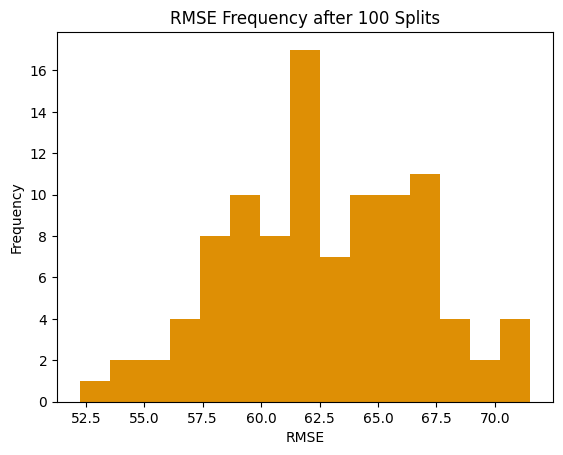

In [4]:
#plotting histogram of RMSE
plt.hist(split_rmse, bins=15, color='#DE8F05')
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.title("RMSE Frequency after 100 Splits")
plt.show()

**1.2 (4 points)** The model is the same every time; only the split changes. Describe the spread you see. If you had made just one split and reported its test RMSE, how much would you trust that number? What would you need to know to trust it more?

**Your answer:**

The frequency of the RMSE appears to trend toward normal. I think that if we did this same process over and over, increasing the number of train/test splits, as we approached infinity (assuming there was enough data to do that!) we would move closer and closer to a normal distribution.

The mean is 62.74 of all the training/test splits with a 4.08 standard deviation and a difference of about 20 between the minimum and maximum RMSE.

That means that if you did only one test, you might end up with a situation where your RMSE is as much as 10 off from the mean of all the tests. So there is quite a bit of variation in the result depending on what makes it into the training data. I would therefore have little confidence in the results of just one test. You would need to do something like this where you split the data up different ways before you test/train in order to understand the data a bit better.


## Part 2 - $k$-Fold Cross-Validation by Hand (25 points)

**2.1 (10 points)** Complete the function below so that it performs $k$-fold cross-validation and returns a NumPy array of the $k$ fold RMSEs. Follow these steps exactly, so that your folds match scikit-learn's:

1. Shuffle the row indices with `np.random.RandomState(seed).permutation(n)`, where `n` is the number of rows.
2. Split the shuffled indices into `k` folds with `np.array_split`.
3. For each fold `i`, use fold `i` as the test indices and all the other folds, combined with `np.concatenate`, as the training indices. Fit `model` on the training rows and compute the RMSE on the test rows.

*Hint:* NumPy fancy indexing (`X[train_idx]`) is all you need to pull out the rows.

In [5]:
def kfold_rmse(model, X, y, k=5, seed=RANDOM_STATE):

    """Return an array of the k fold RMSEs from k-fold cross-validation."""
    # YOUR CODE HERE

    #assigning n as number of rows (length of y)
    n=len(y)

    #creating empty list for the RMSE
    rmse = []

    #shuffling the indices and splitting them into folds
    indices = np.random.RandomState(seed).permutation(n)
    folds = np.array_split(indices, k)

    #for each fold
    for i in range(k):

        #assigning the test fold by index
        test_idx = folds[i]

        #the rest will be the training data
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        #fitting model with training data
        model.fit(X[train_idx], y[train_idx])

        #predicting with the test data and adding to list
        rmse.append(root_mean_squared_error(y[test_idx], model.predict(X[test_idx])))

    #converting to array
    rmse_array = np.array(rmse)

    return rmse_array


In [6]:
my_folds = kfold_rmse(small_tree(), X, y, k=5)
print("Fold RMSEs:", my_folds.round(2))
print(f"CV estimate (mean fold RMSE): {my_folds.mean():.2f}")

Fold RMSEs: [59.6  61.02 66.46 64.23 61.55]
CV estimate (mean fold RMSE): 62.57


**2.2 (5 points)** Now check your work with scikit-learn. Use `cross_val_score` on `small_tree()` with `cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)` and `scoring='neg_root_mean_squared_error'`. scikit-learn always *maximizes* scores, so error metrics come back negated; flip the sign. Store the result in `sk_folds`, print it, and confirm with `np.allclose` that it matches your fold RMSEs exactly.

In [7]:
# YOUR CODE HERE
sk_folds = -cross_val_score(small_tree(), X, y, cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring='neg_root_mean_squared_error')

#comparing arrays
np.allclose(my_folds, sk_folds)


True

**2.3 (5 points)** How should we choose $k$? For each $k$ in `[2, 5, 10, 20, n]`, where `n = len(y)`, run `cross_val_score` on `small_tree()` with a shuffled `KFold` (same `random_state`) and **`scoring='neg_mean_squared_error'`**. Compute the CV estimate as the square root of the average fold MSE, and time each run with `time.time()`. Print a small table (a DataFrame is fine) of $k$, the CV RMSE, and the run time.

When $k = n$, each fold holds a single observation. This is called **leave-one-out cross-validation (LOOCV)**.

*Why MSE here?* With one observation per fold, a fold's "RMSE" is just the absolute value of a single error, so averaging fold RMSEs would give the mean *absolute* error, not the RMSE. Averaging MSEs first, as in the $\text{CV}_{(k)}$ formula, is correct for every $k$.

In [8]:
n = len(y)
rows = []

# YOUR CODE HERE

#list of k's
ks = [2, 5, 10, 20, n]

#lists for the CV RMSE and run time
CV_RMSE = []
run_time = []

for k in ks:
  #starting the clock!
  start = time.time()

  #running cross_val_score using the k's in the list
  CV = -cross_val_score(small_tree(), X, y, cv=KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE), scoring='neg_mean_squared_error')

  #calculating the CV_RMSE by taking the square root of the mean and adding it to the list
  CV_RMSE.append(np.sqrt(CV.mean()))

  #adding how long it took to its list, and assembling everything together in list 'rows'
  run_time.append(time.time() - start)
  rows.append([k, CV_RMSE[-1], run_time[-1]])

#making a dataframe out of the rows
pd.DataFrame(rows)

#printing results
pd.DataFrame(rows, columns=["k", "CV_RMSE", "run_time"])

,k,CV_RMSE,run_time
0,2,63.755365,0.024349
1,5,62.619900,0.026193
2,10,63.164629,0.039056
3,20,61.360320,0.061193
4,442,59.516857,1.328494


**2.4 (5 points)** Part 1 showed that a single split's estimate varies a lot. Does the 5-fold CV estimate vary less? Compute the 5-fold CV RMSE (the mean of `kfold_rmse(small_tree(), X, y, k=5, seed=seed)`) for each `seed` from 0 to 99, store the results in `cv_estimates`, and print their minimum, maximum and standard deviation. Compare them to Part 1, then answer the questions below.

In [9]:
cv_estimates = []

# YOUR CODE HERE

for seed in range(100):
  cv_estimates.append(kfold_rmse(small_tree(), X, y, k=5, seed=seed).mean())

#printing stats

cv_estimates = np.array(cv_estimates)

#printing stats
print(
    f"Minimum: {np.array(cv_estimates).min():.2f}"
    f"\nMaximum: {np.array(cv_estimates).max():.2f}"
    f"\nMean: {np.array(cv_estimates).mean():.2f}"
    f"\nStandard Deviation:  {np.array(cv_estimates).std():.2f}"
)

Minimum: 60.35
Maximum: 65.51
Mean: 62.86
Standard Deviation:  1.11


Why is the 5-fold estimate more stable than a single split? In 2.3, the CV estimate tends to get *smaller* as $k$ grows. Why might that be? What are the trade-offs in choosing $k$, and why are $k = 5$ and $k = 10$ such common choices?

**Your answer:**
The 5-fold estimate is more stable than a single split, because when you perform a single split, you might put, like we did in our example, 20% of the data into the test set and train the model on the other 80%. Depending on what data ends up in what set, we see varying results.

When we do a 5-fold split, we split the data into 5 groups and train the model 5 times. Then you average the results, which is going to give you a more centralized idea of what is happening. Rather than just some random data ending up in the training set, all of the data figures into the training $k-1$ times. Taking the average stabilizes the model as the effect of outliers is minimized.


The CV estimates tend to get smaller as $k$ increases because the proportion of the data the model is trained on each round increases. For example, if you have $k=2$, then there are 2 rounds of 50% of the data being trained at a time. If you have $k=5$, then there are 5 rounds and 80% of the data is being trained each time.

I would assume this is why $k=5$ and $k=10$ are such commmon choices. When $k=5$, 80% of the data is being trained each time, which is a significant proportion of the data but also leaves a full 20% each time for testing. When $k=10$, 90% gets trained each round, and 10% is used for testing.

As $k$ increases, the number of rounds increases, which means the trade-off for choosing larger and larger $k$ values is that the training is going to take longer and be more expensive overall. $k=5$ and $k=10$ are probably large enough to be useful increases in $k$ without being too costly. If $k=n$ and n represents millions of rows of data, then the model might indeed benefit from being trained millions of times, but you might never find that out, because fitting it millions of times would take far too long!


## Part 3 - Tuning the Depth of a Decision Tree (20 points)

Now we'll use cross-validation for its second job: choosing a hyperparameter. We'll generate data where we *know* the true function, $f(x) = \sin(2\pi x)$, plus normal noise with standard deviation 0.3, and fit decision trees of different maximum depths. The depth is the hyperparameter.

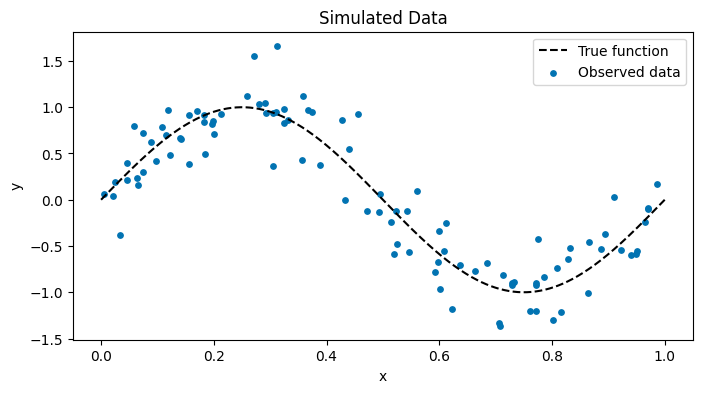

In [10]:
rng = np.random.RandomState(RANDOM_STATE)
n_points = 100
x = np.sort(rng.uniform(0, 1, n_points))
y_sim = np.sin(2 * np.pi * x) + rng.normal(0, 0.3, n_points)
X_sim = x.reshape(-1, 1)  # scikit-learn wants a 2D array of features

def depth_tree(depth):
    """A decision tree regressor with the given maximum depth."""
    return DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8, 4))
grid = np.linspace(0, 1, 500)
ax.plot(grid, np.sin(2 * np.pi * grid), color='black', linestyle='--', label='True function')
ax.scatter(x, y_sim, color=BLUE, s=15, label='Observed data')
ax.set_title("Simulated Data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

**3.1 (10 points)** For each depth from 1 to 12, compute:
* the **training RMSE**: fit `depth_tree(depth)` on all 100 points and compute the RMSE on those same points; and
* the **10-fold CV RMSE**: use `cross_val_score` with `cv=KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)` and `scoring='neg_root_mean_squared_error'`, and average the fold RMSEs.

Store the results in arrays `train_rmse` and `cv_rmse`. Plot both against depth on the same axes, then find the depth with the lowest CV RMSE, store it as `best_depth`, and print it.

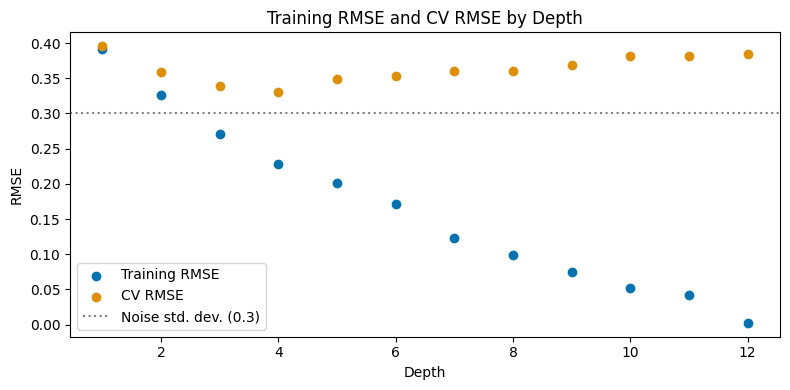

Best depth: 4


In [11]:
depths = np.arange(1, 13)
train_rmse = []
cv_rmse = []

# YOUR CODE HERE

for depth in depths:
  #creating decision tree and saving it
  tree = depth_tree(depth)
  tree.fit(X_sim, y_sim)

  #using model to predict
  y_pred = tree.predict(X_sim)

  train_rmse.append(root_mean_squared_error(y_sim, y_pred))

  #cross validation with 10 folds
  cv_rmse.append(-cross_val_score(depth_tree(depth), X_sim, y_sim, cv=KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE), scoring='neg_root_mean_squared_error').mean())

#converting to arrays
train_rmse, cv_rmse = np.array(train_rmse), np.array(cv_rmse)

#plotting arrays against depth
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(depths, train_rmse, color='#0173B2', label="Training RMSE")
ax.scatter(depths, cv_rmse, color='#DE8F05', label="CV RMSE")

ax.axhline(0.3, color='gray', linestyle=':', label='Noise std. dev. (0.3)')

ax.set_xlabel("Depth")
ax.set_ylabel("RMSE")
ax.set_title("Training RMSE and CV RMSE by Depth")
ax.legend()

fig.tight_layout()
plt.show()

#storing and printing best depth
best_depth = depths[np.argmin(cv_rmse)]

print("Best depth:", best_depth)

**3.2 (5 points)** Use the provided function below to plot the fitted trees' predictions for depth 1, your `best_depth`, and depth 12. (Just run the cell once `best_depth` is defined.)

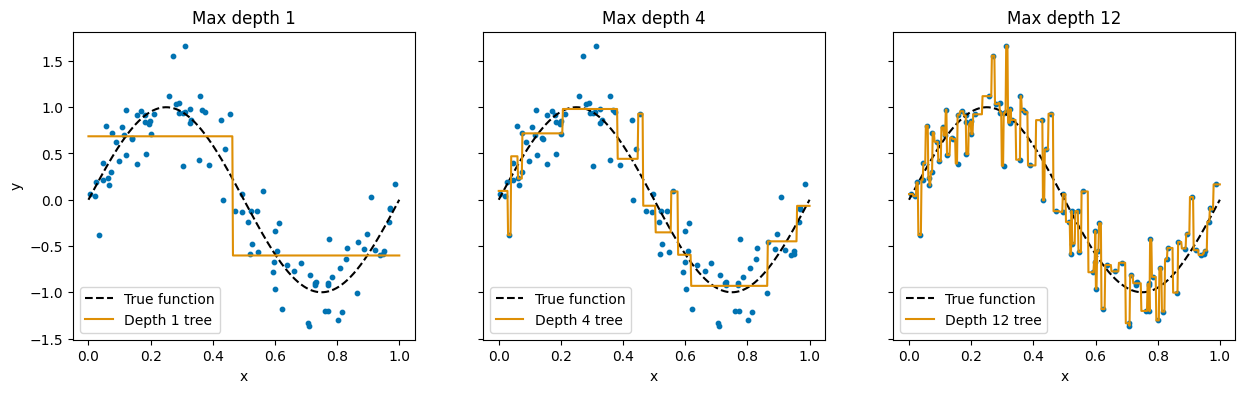

In [12]:
def plot_fits(depth_list):
    fig, axes = plt.subplots(1, len(depth_list), figsize=(5 * len(depth_list), 4), sharey=True)
    for ax, d in zip(axes, depth_list):
        model = depth_tree(d).fit(X_sim, y_sim)
        ax.plot(grid, np.sin(2 * np.pi * grid), color='black', linestyle='--', label='True function')
        ax.plot(grid, model.predict(grid.reshape(-1, 1)), color=ORANGE, label=f'Depth {d} tree')
        ax.scatter(x, y_sim, color=BLUE, s=10)
        ax.set_title(f"Max depth {d}")
        ax.set_xlabel("x")
        ax.legend(loc='lower left')
    axes[0].set_ylabel("y")
    plt.show()

plot_fits([1, best_depth, 12])

**3.3 (5 points)** Which depth does cross-validation choose? Why does the training RMSE keep decreasing as the depth goes up, and why is it a bad guide for choosing the depth? Use the terms *underfitting* and *overfitting*, and refer to the plots in 3.2. Finally, the dotted line marks the standard deviation of the noise we added. Why can't any model have a CV RMSE much below it?

**Your answer:**

Cross validation chose a depth of 4 for the decision tree because it represents the minimum CV RSME over all 12 depths tested.

As depth goes up, we see the RMSE go down. Basically as the depth increases, the model is starting to conform more and more to the data points, basically just "memorizing" the data. As it does this, the RMSE goes down because the residuals are going to decrease more and more as the individual data points are increasingly accomodated. While this overfit model might do a great job describing the sample we have, if we were to then use this model to try to predict new data, it would do a terrible job, because it would basically just replicating the observations it was trained on.

In contrast, the Depth 1 tree is underfit and account for enough variation in the actual data. It underestimates what is going on and oversimplifies the true function to the point where it is not useful for prediction.

No model can have a CV RMSE much lower than the standard deviation of the noise because no matter how good a model is, there will always be random noise that will affect data, even if it is just measurement error. You can get closer and closer to modeling the true population regression, but there is always going to be some degree of a residual that is going to "mess up" its actual predictive power.

In the case of our randomly generated data in this example, we can push the RMSE lower and lower with more depth in the model, but pushing the RMSE toward 0 doesn't create a perfect predictor because the model is built around the specific noise in the data. Even with a reasonable model like the one that goes to Depth 4, future observations are going to have their own noise that make observed values differ from predicted ones.

Mathematically, it has to do with the expected value of the squared error in normally distributed errors, which is:

\begin{equation}
E[\epsilon^2] = \sigma^2
\end{equation}

(This is in a homoskedastic dataset that doesn't demonstrate autocorrelation or other complicating factors.) That means that the best possible RMSE is the root of that squared error or:

 \begin{equation}
\sqrt{\sigma^2} = \sigma
\end{equation}

which, of course is the standard deviation.

## Part 4 - Tuning a Random Forest (20 points)

Now a classification problem. The **breast cancer** dataset has 569 tumors described by 30 numeric features computed from images, each labeled malignant (0) or benign (1). We'll use a `RandomForestClassifier`, which has several hyperparameters:
* `n_estimators`: the number of trees in the forest;
* `max_features`: how many features each split may choose from (`'sqrt'` means $\sqrt{30} \approx 5$, a number like `0.5` means that fraction of the features, and `1.0` means all of them, which is plain bagging); and
* `min_samples_leaf`: the smallest number of training points allowed in a leaf.

First we set aside a test set that we won't touch until the very end. `stratify=yb` keeps the same proportion of malignant and benign tumors in both sets, and `StratifiedKFold` does the same for each fold.

In [13]:
Xb, yb = load_breast_cancer(return_X_y=True)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, stratify=yb, random_state=RANDOM_STATE)

print("Training set:", Xb_train.shape, "Test set:", Xb_test.shape)
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

Training set: (455, 30) Test set: (114, 30)


**4.1 (8 points)** How many trees do we need? For each value in `tree_counts` below, use `cross_val_score` with `cv=cv_strat` on the **training set** to evaluate `RandomForestClassifier(n_estimators=..., random_state=RANDOM_STATE, n_jobs=-1)`. (Accuracy is the default score for classifiers; `n_jobs=-1` uses all your processor cores.) Store the mean and standard deviation of the fold accuracies in `forest_mean` and `forest_std`.

Also compute the 10-fold CV accuracy of a single `DecisionTreeClassifier(random_state=RANDOM_STATE)` as `tree_acc`.

Plot `forest_mean` against the number of trees with a log-scale $x$-axis (`ax.set_xscale('log')`), shade a band of $\pm$ one standard deviation with `ax.fill_between`, and draw a horizontal line at `tree_acc` for comparison.

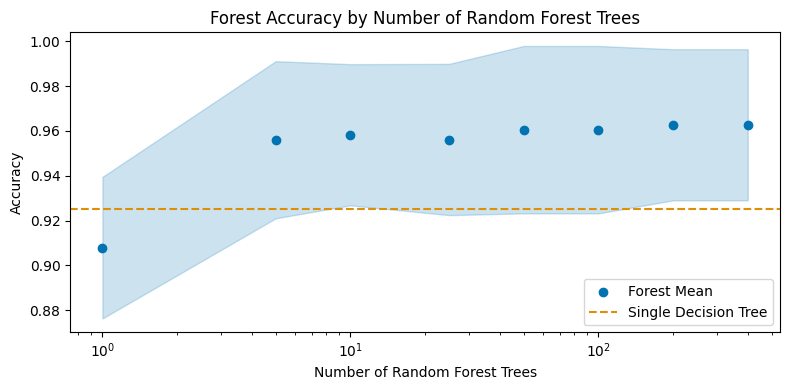

In [14]:
tree_counts = [1, 5, 10, 25, 50, 100, 200, 400]
forest_mean, forest_std = [], []

# YOUR CODE HERE
for tree in tree_counts:

  #cross validation using the random forest classifier and a number of trees from the list
  stats = cross_val_score(RandomForestClassifier(n_estimators=tree, random_state=RANDOM_STATE, n_jobs=-1), Xb_train, yb_train, cv=cv_strat)

  #appending stats to lists
  forest_mean.append(stats.mean())
  forest_std.append(stats.std())

#calculating avg 10 fold CV accuracy of one DecisionTreeClassifier
tree_acc = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE), Xb_train, yb_train, cv=cv_strat).mean()

#converting to arrays
forest_mean, forest_std = np.array(forest_mean), np.array(forest_std)

#plotting forest_mean against number of trees
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(tree_counts, forest_mean, color='#0173B2', label="Forest Mean")

#setting x axis to log x axis values
ax.set_xscale('log')

#creating a band between +- 1 std
ax.fill_between(tree_counts, forest_mean - forest_std, forest_mean + forest_std, color='#0173B2', alpha=0.2)

#plotting a single line at the single tree accuracy score
ax.axhline(tree_acc, color='#DE8F05', linestyle='--', label="Single Decision Tree")

ax.set_xlabel("Number of Random Forest Trees")
ax.set_ylabel("Accuracy")
ax.set_title("Forest Accuracy by Number of Random Forest Trees")
ax.legend()

fig.tight_layout()
plt.show()

**4.2 (6 points)** Rather than writing loops, we can let `GridSearchCV` do the search. Use `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)` and search over `max_features` in `['sqrt', 0.5, 1.0]` and `min_samples_leaf` in `[1, 3, 5, 10]`, with `cv=cv_strat` and `n_jobs=-1`. Fit it on the training set and store it as `forest_search`.

Print `best_params_` and `best_score_`. By default, `GridSearchCV` then refits the best model on the whole training set, so finally compute its accuracy on the held-out test set. The provided code after your cell prints the CV accuracy for every combination.

In [15]:
# YOUR CODE HERE
max_features = ['sqrt', 0.5, 1.0]
min_samples_leaf = [1, 3, 5, 10]

#making a grid from the lists
param_grid = {'max_features': max_features, 'min_samples_leaf': min_samples_leaf}

#searching over features and fitting on training set
forest_search = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), param_grid, cv=cv_strat, n_jobs=-1).fit(Xb_train, yb_train)

#printing parameters and accuracies
print("Best parameters:", forest_search.best_params_)
print("Best CV accuracy:", forest_search.best_score_)
print("Test accuracy:", forest_search.score(Xb_test, yb_test))

Best parameters: {'max_features': 0.5, 'min_samples_leaf': 1}
Best CV accuracy: 0.9692270531400966
Test accuracy: 0.956140350877193


In [16]:
# Provided: CV accuracy for every combination in the grid (run after 4.2).
results = pd.DataFrame(forest_search.cv_results_)
results['param_max_features'] = results['param_max_features'].astype(str)
results.pivot(index='param_max_features', columns='param_min_samples_leaf',
              values='mean_test_score').round(4)

param_min_samples_leaf,1,3,5,10
param_max_features,,,,
0.5,0.9692,0.9627,0.9605,0.9495
1.0,0.9627,0.9604,0.9539,0.9451
sqrt,0.9606,0.9539,0.9583,0.9540


**4.3 (6 points)** Answer the following.
1. How does the forest compare with a single decision tree, and why does averaging many trees help? What role does `max_features` play?
2. Does adding more trees ever make the forest overfit, based on your plot? Why do people usually just pick a reasonably large `n_estimators` instead of tuning it the way we tuned depth in Part 3?
3. In the clustering lecture we saw that features should be scaled before computing distances. We never scaled the features here. Why don't decision trees and random forests need scaled features?

**Your answer:**
1. The single decision tree and the random forest are different models. The single decision tree works by feeding in a training set, and the classifier tries at every level to find the optimal split(s) and thresholds at which to do the split. It does this on the whole set with all the features it's told to try.

The random forest model, on the other hand is a bagging ensemble. Essentially you are training the algorithm multiple times on random subsets of the training set. The sampling is done with replacement, meaning the same data point could actually occur multiple times in the same sample (this is essentially boostrapping.) At each branch, the set of features used is also randomly selected from the pool of all features. Then the predictions from all the predictors are aggregated, which increases stability and reduces variance when compared to a single decision tree.

The *max_features* hyperparameter indicates the maximum number of features that can be considered for splitting nodes. So if you had 10 features but you set the *max_features* to 3, at each node the model would randomly select 3 of the 10 and find the best split with those randomly chosen features.

2. Adding more trees to the random forest doesn't cause overfitting the way adding more nodes and splits to a decision tree might. The plot above shows that the accuracy doesn't change too much past 5 trees. 5, 10, and even 400 trees all produce a relatively similar level of accuracy. Because the predictions are aggregated, the predictions actually become more stable and variance is reduced the more trees you add. So you're not risking overfitting because the skew of outlying results is being reduced by the aggregation.  

The plot also indicates that you don't really need to be too precise about the number of trees. All the forests from 5-400 trees we tested ended up demonstrating about the same level of accuracy. You want to make sure you have enough to do the job, but you don't have to hit some perfect number of trees to get a satisfactory result.

3. Decision trees and random forests don't need scaling because they are comparing where the observations fall relative to the threshold. So you while you could scale the observations, you don't need to because the split is being decided upon based on what is happening in the feature and where the best split would be relative to the values it contains, not based on the objective quantities or values those numbers represent. The model doesn't need them to be on a specific scale to be able to find the threshold for the best split.

## Part 5 - Data Leakage: How Cross-Validation Goes Wrong (15 points)

Cross-validation only works if *every* step that learns from the data is repeated inside each fold. Here's a dramatic example of what happens when that rule is broken.

We'll create a dataset of 100 observations with **5,000 features of pure random noise** and labels assigned completely at random. No model can genuinely predict these labels better than 50% accuracy.

In [17]:
rng = np.random.RandomState(RANDOM_STATE)
X_noise = rng.normal(size=(100, 5000))
y_noise = np.array([0, 1] * 50)
rng.shuffle(y_noise)

cv5_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

With so many features, we'd like to keep only the most useful ones. `SelectKBest(f_classif, k=20)` keeps the 20 features most strongly associated with the labels. Like an imputer or an encoder, it has `fit` and `transform` methods: `fit` learns which features to keep, and `transform` keeps them.

**5.1 (5 points) The wrong way.** Fit `SelectKBest(f_classif, k=20)` on **all** of `X_noise` and `y_noise`, and transform to get the 20 selected features. Then run `cross_val_score` with `RandomForestClassifier(random_state=RANDOM_STATE)` on those 20 features, using `cv=cv5_strat`. Print the mean CV accuracy.

In [18]:
# YOUR CODE HERE

#selecting 20 features most associated with labels
get_features = SelectKBest(f_classif, k=20).fit(X_noise, y_noise)

#keeping those features
keep_features = get_features.transform(X_noise)

#calculating mean CV accuracy
m_CV_accuracy = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE), keep_features, y_noise, cv=cv5_strat).mean()
print(m_CV_accuracy)

0.8099999999999999


**5.2 (5 points) The right way.** Put the selector and the forest together in a pipeline, `make_pipeline(SelectKBest(f_classif, k=20), RandomForestClassifier(random_state=RANDOM_STATE))`, and run `cross_val_score` on the *full* `X_noise` with the same `cv`. A pipeline runs its steps in order, and cross-validating it re-fits *every* step on the training folds only. Print the mean CV accuracy.

In [19]:
# YOUR CODE HERE

#making pipeline
my_pipe = make_pipeline(SelectKBest(f_classif, k=20), RandomForestClassifier(random_state=RANDOM_STATE))

#calculating mean CV accuracy
new_mean_CV_accuracy = cross_val_score(my_pipe, X_noise, y_noise, cv=cv5_strat).mean()
print(new_mean_CV_accuracy)

0.5


**5.3 (5 points)** Explain the difference between the two results. Where exactly did information leak in 5.1, and why does the pipeline in 5.2 fix it? State a general rule for using cross-validation correctly.

**Your answer:**

The information leaked right in the first line of code in 5.1. The first thing we did was to find the 20 features most associated with the labels, and *SelectKBest* does this by looking through *all* of the observations. So then when we do the cross validation afterwards, the selected validation instances have already been "seen" by the model because they were used to pick the 20 most associated labels in the first place. You can see it in our example: the "wrong" way produced an over-inflated accuracy score, whereas the "right" way tells us the reality of the model's predictive power really being no better than random chance.

The pipeline fixes the problem by separating the training instances from the validation instances BEFORE the model looks for the features. That way the content of the validation set isn't influencing what features are being chosen.

A general rule would be: the learning has to happen within the cross validation. If that includes selection of features, that has to happen only on the training data, within the CV.

## Part 6 - Putting It Together (10 points)

Back to the diabetes data. We'll tune both a single decision tree and a random forest, compare them with cross-validation, and hold out a final test set the way we would in a real project.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
cv10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

**6.1 (6 points)** Run two grid searches on the training set, both with `cv=cv10` and `scoring='neg_root_mean_squared_error'`:
* `tree_search`: `DecisionTreeRegressor(random_state=RANDOM_STATE)`, searching `max_depth` from 1 to 10 and `min_samples_leaf` in `[1, 5, 10, 20, 40]`.
* `forest_reg_search`: `RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)`, searching `max_features` in `[0.33, 0.5, 1.0]` and `min_samples_leaf` in `[1, 5, 10, 20]`. Pass `n_jobs=-1` to `GridSearchCV`; this one takes a little while.

For each, print the best parameters, the best CV RMSE (remember the sign) and the RMSE on the test set. The provided code after your cell draws a heatmap of the tree's CV RMSE for every combination in its grid.

In [21]:
# YOUR CODE HERE

#lists
max_depth = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
min_samples_leaf_1 = [1, 5, 10, 20, 40]
max_features = [0.33, 0.5, 1.0]
min_samples_leaf_2 = [1, 5, 10, 20]

#making grids from the lists
param_grid_1 = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf_1}
param_grid_2 = {'max_features': max_features, 'min_samples_leaf': min_samples_leaf_2}

#searching features and fitting on training sets
tree_search = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), param_grid_1, cv=cv10, scoring='neg_root_mean_squared_error').fit(X_train, y_train)

forest_reg_search = GridSearchCV(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), param_grid_2, cv=cv10, scoring='neg_root_mean_squared_error', n_jobs=-1).fit(X_train, y_train)

#printing parameters and accuracies
print("Best Tree Parameters:", tree_search.best_params_)
print("Best Tree CV RMSE:", -tree_search.best_score_)
print("Tree Test RMSE:", -tree_search.score(X_test, y_test))
print()
print("Best Forest Parameters", forest_reg_search.best_params_)
print("Best Forest CV RMSE:", -forest_reg_search.best_score_)
print("Forest Test RMSE:", -forest_reg_search.score(X_test, y_test))


Best Tree Parameters: {'max_depth': 2, 'min_samples_leaf': 1}
Best Tree CV RMSE: 62.68834393199027
Tree Test RMSE: 61.1187337707425

Best Forest Parameters {'max_features': 0.33, 'min_samples_leaf': 5}
Best Forest CV RMSE: 56.613707508423296
Forest Test RMSE: 52.716335803690285


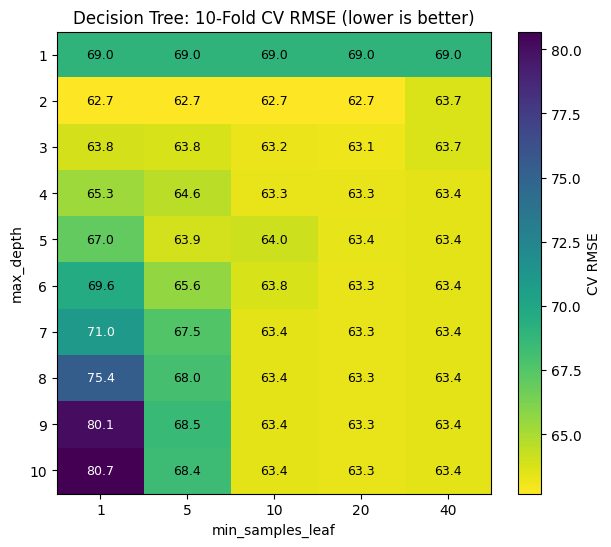

In [22]:
# Provided: heatmap of the decision tree's CV RMSE over its grid (run after 6.1).
results = pd.DataFrame(tree_search.cv_results_)
table = results.pivot(index='param_max_depth', columns='param_min_samples_leaf',
                      values='mean_test_score') * -1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(table.values, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(table.columns)), labels=table.columns)
ax.set_yticks(range(len(table.index)), labels=table.index)
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(j, i, f"{table.values[i, j]:.1f}", ha='center', va='center',
                color='white' if table.values[i, j] > 70 else 'black', fontsize=9)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")
ax.set_title("Decision Tree: 10-Fold CV RMSE (lower is better)")
fig.colorbar(im, ax=ax, label="CV RMSE")
plt.show()

**6.2 (4 points)** Which model would you choose for this problem, and why? What pattern do you see in the tree's heatmap, and what does it say about how its two hyperparameters interact? Finally, why don't the CV RMSE and the test RMSE match exactly, and why do we look at the test set only once, at the very end?

**Your answer:**

I would definitely choose the random forest because the CV RMSE for the random forest with the best parameters is lower than it is for the decision tree with the best parameters, meaning that overall it performed better. It also performed better on the test data that we saved for the end. In fact, it did better on the test data than it did during CV. To me that's not too surprising given what we saw earlier. This random forest model was able to generalize better, which would likely make it perform better on unseen data because of its stability.

In the decision tree's heatmap, where the minimum samples per leaf is 1, we see the CV RMSE improving greatly from depth 1 to depth 2, but then as depth continues to increase, the CV RMSE gets progressively worse. The same pattern can be seen when the minimum samples per leaf is 5, except that the progression toward higher CV RMSEs is slower. Generally speaking, that pattern seems to hold as we move right, with the CV RMSE rising as depth increases, but the rate at which that happens increasingly slowing down. Basically we are seeing the interaction of two things that influence complexity of the tree. Higher minimum leaf counts and lower depths can both help prevent overfitting, and we can see in the heatmap that wherever that leaf count is high or the depth is low, the CV RMSE is lower.

The CV RMSE and the test RMSE don't match exactly because the CV RMSE comes from the training set, and the test RMSE comes from the test set, which was separated out before CV began. The CV RMSE represents the average performance of the model on the different folds that all came from the training set. Whatever ended up in the test set could be easy to predict, or it could be harder. But it makes sense that once the best parameters have been identified and the model is refit using all the training data, the RMSE could be smaller than the CV RMSE because the final fit is looking at everything (except the test data) all at once.  